In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

Q6. Load the Boston Housing dataset and perform basic data exploration using:

. head()

. info()

. describe()

In [4]:
df = pd.read_csv("BostonHousing.csv")

df.head()

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


Q7. Perform Exploratory Data Analysis:

. Create pairplot

. Create correlation heatmap

. Identify which features are highly correlated with house price (medv)

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


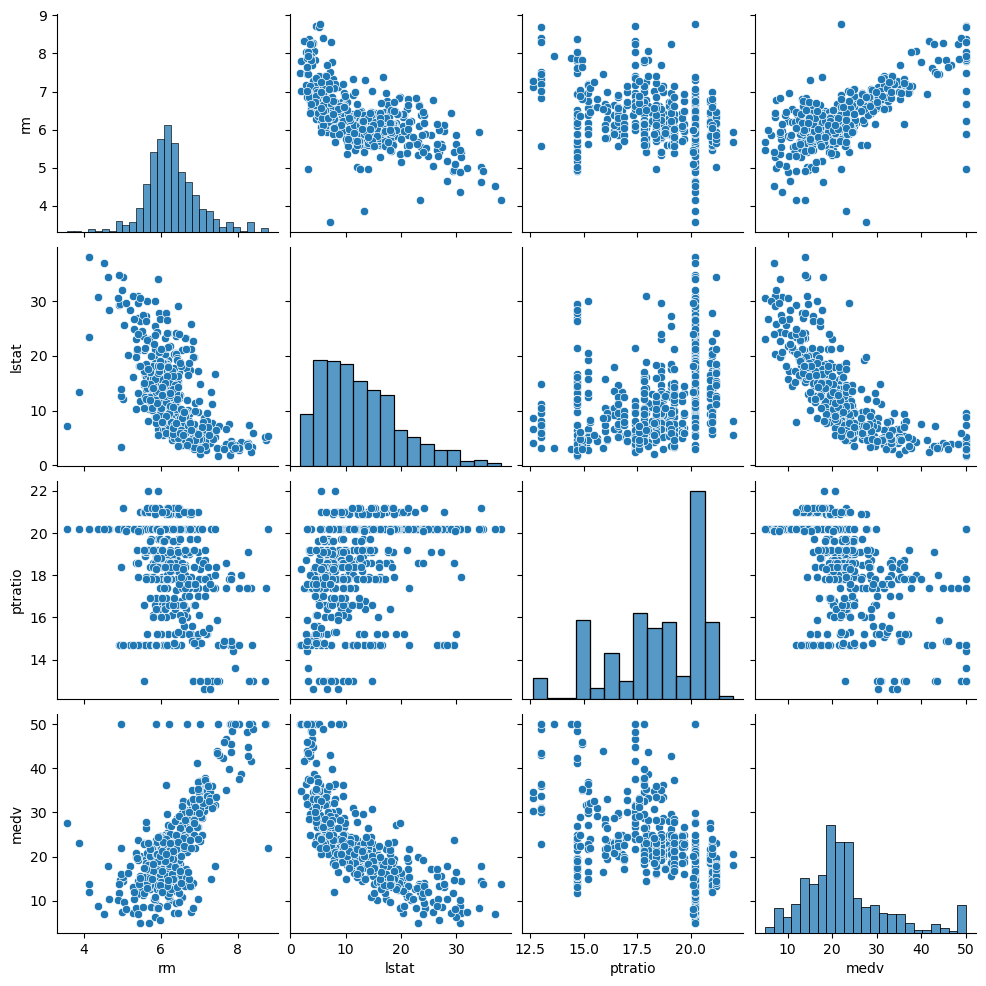

In [5]:
sns.pairplot(df[['rm', 'lstat', 'ptratio', 'medv']])

plt.show()

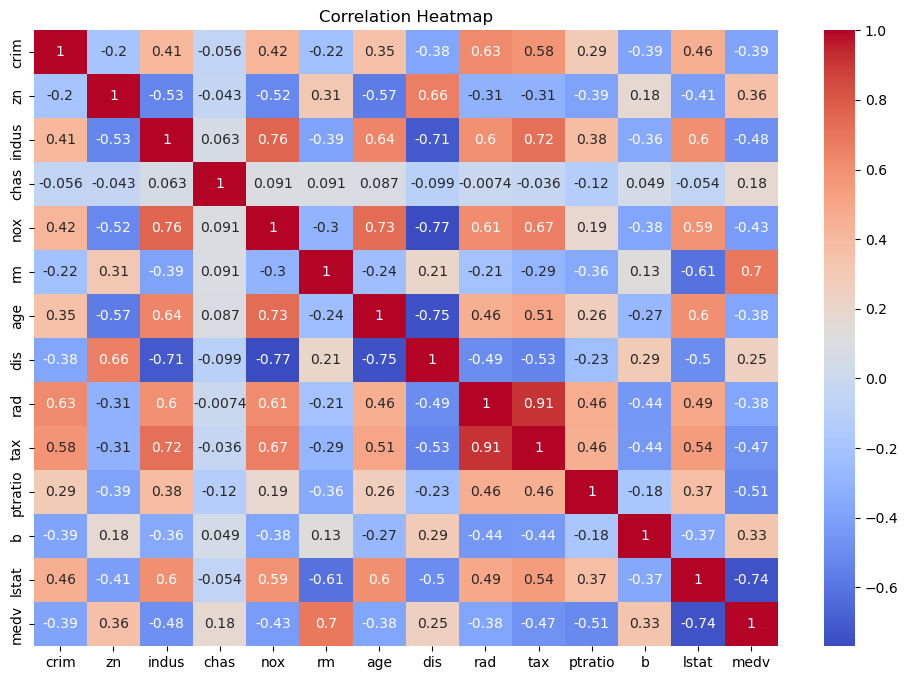

In [6]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [7]:
df.corr()['medv'].sort_values(ascending=False)

medv       1.000000
rm         0.695360
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64

Q8. Select independent variables (features) and dependent variable (target). 
 Target variable: medv (house price)

In [8]:
y = df['medv']    # Target variable 

X = df.drop('medv', axis=1)  # Feature Variable

Q9. Split the dataset into training and testing sets (80% training, 20% testing). 


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)       #80% data used for training
                           #20% data used for testing

Q10. Train a Linear Regression model and perform the following:

. Make predictions

. Calculate MAE

. Calculate MSE

. Calculate RMSE

. Calculate R² Score

. Calculate Adjusted R²

. Write the Linear Regression equation

. Interpret the model coefficients 

In [10]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred = model.predict(X_test)

In [12]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 3.189091965887841


In [14]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 24.291119474973474


In [15]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 4.928602182665332


In [16]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.6687594935356327


In [17]:
print("Intercept:", model.intercept_)

coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coeff_df)

Intercept: 30.246750993923857
    Feature  Coefficient
0      crim    -0.113056
1        zn     0.030110
2     indus     0.040381
3      chas     2.784438
4       nox   -17.202633
5        rm     4.438835
6       age    -0.006296
7       dis    -1.447865
8       rad     0.262430
9       tax    -0.010647
10  ptratio    -0.915456
11        b     0.012351
12    lstat    -0.508571


## Regression Equation

[
MEDV = b_0 + b_1(X_1) + b_2(X_2) + b_3(X_3) + \cdots
]

Example:

[
MEDV = 36.45 - 0.10(CRIM) + 4.20(RM) - 0.95(LSTAT)
]

# Interpretation of Model Coefficients

| Feature | Interpretation                                 |
| ------- | ---------------------------------------------- |
| RM      | More rooms increase house price                |
| CRIM    | Higher crime rate decreases house price        |
| LSTAT   | Higher lower-status population decreases price |
| PTRATIO | Higher student-teacher ratio reduces price     |

# Final Conclusion

1. Linear Regression was successfully applied on the Boston Housing dataset.
2. `RM` has strong positive impact on house prices.
3. `LSTAT` negatively affects house prices.
4. The model achieved good prediction accuracy using R² score.
5. Heatmap and pairplot helped identify important relationships between variables.
